In [172]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
from math import factorial as ft 
import plotly.express as px
plt.style.use('ggplot')

In [173]:
df_survey = pd.read_csv('/Users/leahdeyoung/Desktop/GitHub/re_new_repos/the-bronfman-fellowship/2025_Campus_Commons_Program_Evaluation-2025-05-09-12-18-38.csv', encoding = "utf-8")


In [174]:
display(df_survey.sample(10))

,Application ID,Application Title,Applicant First Name,Applicant Last Name,Applicant Email Address,Applicant System ID,Program Name,"Campus Commons fellows are encouraged to participate in a research partnership between The Bronfman Fellowship and CASJE (Collaborative for Applied Studies in Jewish Education) at The George Washington University. Study participants will fill out a short form and participate in one or two interviews, with an opportunity to earn up to $100. The study will explore Jewish undergraduate bridge-builders’ experiences on campus, and how Jewish identity relates to bridge-building work. The study will be conducted by Dr. Elana Riback Rand, a post-doctoral research fellow at CASJE. You can email Elana at elana.rand@gwu.edu for any questions.This study is completely separate from your Campus Commons fellowship. You are under no obligation to participate in the study. Please indicate whether you are interested in learning more about this project.","""Post-Program Evaluation"" completion status","""Post-Program Evaluation"" completion date/time",...,"Were there any topics or perspectives you felt hesitant to express during Campus Commons? If so, what contributed to this hesitation? If not, what helped create an environment where you felt comfortable sharing your views?","After participating in Campus Commons, how likely are you to… | Engage in additional bridge building opportunities","After participating in Campus Commons, how likely are you to… | Seek out Jewish community","After participating in Campus Commons, how likely are you to… | Participate in the Campus Commons alumni network and programming","After participating in Campus Commons, how likely are you to… | Stay connected with Campus Commons staff team & faculty","After participating in Campus Commons, how likely are you to… | Stay connected with members of my Campus Commons cohort",Would you recommend Campus Commons to someone else?,Please elaborate on your answer to the previous question.,The Zoom model is still something that we’re adjusting. What is one thing you enjoyed about the experience and one thing that was difficult about the experience?,"Thank you for taking time to complete this survey! If you have any questions or want to share anything else, please add it here:"
31,2024--1528667459,2024--1528667459,Noah,Kassis,noah.kassis@gmail.com,129219944,Campus Commons Application Spring 2025,"Yes, I am interested in learning more about th...",Completed,2025-04-28 20:12:32-04:00,...,No,Somewhat likely,Very likely,Very likely,Very likely,Very likely,Yes,"Of course! It was a beautiful experience, I me...",It's been quite difficult to maintain exciteme...,NaN
3,2024--1745180984,Ilan Berdy,Ilan,Berdy,ilan.berdy@gmail.com,98449769,Campus Commons Application Spring 2025,"Yes, I am interested in learning more about th...",Completed,2025-04-28 20:13:59-04:00,...,NaN,Very likely,Very likely,Very likely,Very likely,Very likely,Yes,I would recommend Campus Commons to individual...,The staff seemed to have the technical logisit...,NaN
20,2024--5499783386,Skylar Strudwick,Skylar,Strudwick,strud009@umn.edu,128948623,Campus Commons Application Spring 2025,"Yes, I am interested in learning more about th...",Completed,2025-04-28 20:11:42-04:00,...,I've been surprisingly open with all of my vie...,Very likely,Very likely,Very likely,Somewhat likely,Very likely,Yes,I would recommend Campus Commons to people who...,I found the length to be a little bit much. I ...,"I've really appreciated the opportunity, thank..."
5,2024--4426621767,Julian Brenman,Julian,Brenman,brenmanj@gmail.com,99215892,Campus Commons Application Spring 2025,"No, I am not interested in learning more about...",Completed,2025-04-28 20:11:23-04:00,...,NaN,Very likely,Very likely,Very likely,Very likely,Very likely,Yes,It was so good for me so I want others to grow...,I loved bthe reminders to keep in touch - the ...,"I love everything I learned , you guys really ..."
19,2024--9003546296,Alex Vtorov

In [175]:
df_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 63 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          Non-Null Count  Dtype  
---  ------         

In [176]:
columns_to_drop = ['Application ID', 'Application Title', 'Applicant Email Address', 'Applicant System ID', 'Program Name', '"Post-Program Evaluation" completion status', '"Post-Program Evaluation" completion date/time']

In [177]:
df_survey = df_survey.drop(columns_to_drop, axis=1)
df_survey = df_survey.drop(df_survey.columns[2], axis=1)
df_survey = df_survey.drop(11)
df_survey = df_survey.drop(24)
df_survey = df_survey.drop(0)

In [178]:
df_survey[df_survey.columns[54]] = df_survey[df_survey.columns[54]].fillna('None').astype(str)
df_survey[df_survey.columns[53]] = df_survey[df_survey.columns[53]].fillna('None').astype(str)
df_survey[df_survey.columns[52]] = df_survey[df_survey.columns[52]].fillna('None').astype(str)
df_survey[df_survey.columns[45]] = df_survey[df_survey.columns[45]].fillna('None').astype(str)
df_survey[df_survey.columns[32]] = df_survey[df_survey.columns[32]].fillna('None').astype(str)
df_survey[df_survey.columns[33]] = df_survey[df_survey.columns[33]].fillna('None').astype(str)

In [179]:
display(df_survey.sample(10))

,Applicant First Name,Applicant Last Name,What is your graduation year? [other],Which Jewish campus organizations are you a part of? (Select all that apply),Which Jewish campus organizations are you a part of?,What are your plans for this summer? Please be as specific as possible.,"For the following, please indicate your participation and if you found the experience to be valuable: | Being at Isabella Freedman for the retreat","For the following, please indicate your participation and if you found the experience to be valuable: | Homegroup experience","For the following, please indicate your participation and if you found the experience to be valuable: | Dialogue Labs","For the following, please indicate your participation and if you found the experience to be valuable: | Engaging with Jewish texts (Shiur)",...,"Were there any topics or perspectives you felt hesitant to express during Campus Commons? If so, what contributed to this hesitation? If not, what helped create an environment where you felt comfortable sharing your views?","After participating in Campus Commons, how likely are you to… | Engage in additional bridge building opportunities","After participating in Campus Commons, how likely are you to… | Seek out Jewish community","After participating in Campus Commons, how likely are you to… | Participate in the Campus Commons alumni network and programming","After participating in Campus Commons, how likely are you to… | Stay connected with Campus Commons staff team & faculty","After participating in Campus Commons, how likely are you to… | Stay connected with members of my Campus Commons cohort",Would you recommend Campus Commons to someone else?,Please elaborate on your answer to the previous question.,The Zoom model is still something that we’re adjusting. What is one thing you enjoyed about the experience and one thing that was difficult about the experience?,"Thank you for taking time to complete this survey! If you have any questions or want to share anything else, please add it here:"
3,Ilan,Berdy,2025.0,Hillel,"Hillel,Chabad,Non-Hillel Jewish community orga...",Unknown - hoping to have a job in NY,I participated and found it valuable,I participated and found it valuable,I participated and found it valuable,I participated and found it valuable,...,None,Very likely,Very likely,Very likely,Very likely,Very likely,Yes,I would recommend Campus Commons to individual...,The staff seemed to have the technical logisit...,None
7,Maddy,Hefner,2026.0,Choice 2Chabad,"Chabad,StandWithUs","Volunteering in Israel, seminary and interning",I participated and found it valuable,I participated and found it valuable,I participated but did NOT find it valuable,I participated but did NOT find it valuable,...,I think the calming environment where we were ...,Somewhat likely,Very likely,Very likely,Somewhat likely,Somewhat likely,Yes,None,Breakout rooms were fun but sitting and listen...,None
12,Lauren Emily,Tapper,2027.0,Hillel,Hillel,Goldman Fellow at the American Jewish Committe...,I participated and found it valuable,I participated and found it valuable,I participated and found it valuable,I participated and found it valuable,...,no. getting to know people really helped. i li...,Very likely,Very likely,Somewhat likely,Somewhat likely,Very likely,Yes,This was an incredible program and I recommend...,break out rooms with the homegroups,None
17,Remy,Herrnson,2025.0,Hillel,Hillel,I plan to travel to Europe before pursuing my ...,I participated and found it valuable,I participated and found it valuable,I participated and found it valuable,I participated but did NOT find it valuable,...,none,Very likely,Somewhat likely,Very likely,Very likely,Very likely,Yes,I think it was a great experience that helped ...,one thing I enjoyed was the laid back aspect o...,None
18,Henry,Karpovas Lisak,2027.0,Hillel,"Hillel,Other : ICC - Israel on Campus Coalition",Work as an Engineering Intern,I participated and found it valuable,I participated and found 

In [180]:
df_survey.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 1 to 31
Data columns (total 55 columns):
 #   Column                                                                                                                                                                                                                                         Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                                                         --------------  -----  
 0   Applicant First Name                                                                                                                                                                                                                           29 non-null     object 
 1   Applicant Last Name                                                                          

In [181]:
df_survey = df_survey.reset_index().rename(columns={'For the following, please indicate your participation and if you found the experience to be valuable:  | Being at Isabella Freedman for the retreat': 'Being at Isabella Freedman for the retreat', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Homegroup experience': 'Homegroup experience', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Dialogue Labs': 'Dialogue Labs', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Engaging with Jewish texts (Shiur)': 'Engaging with Jewish texts (Shiur)', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Skills-Based Social Psychology Sessions': 'Skills-Based Social Psychology Sessions', 'For the following, please indicate your participation and if you found the experience to be valuable:  | Middot & Music sessions with Arielle Korman': 'Middot & Music sessions with Arielle Korman'})

In [182]:
value_columns = [
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Being at Isabella Freedman for the retreat',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Homegroup experience',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Dialogue Labs',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Engaging with Jewish texts (Shiur)',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Skills-Based Social Psychology Sessions',
    'For the following, please indicate your participation and if you found the experience to be valuable:  | Middot & Music sessions with Arielle Korman'
]

value_column_rename = [
    'Being at Isabella Freedman for the retreat',
    'Homegroup experience',
    'Dialogue Labs',
    'Engaging with Jewish texts (Shiur)',
    'Skills-Based Social Psychology Sessions',
    'Middot & Music sessions with Arielle Korman'
]

In [183]:
#grp = df_survey.groupby(value_columns)

In [184]:
#df_value = pd.DataFrame()

In [185]:
#df_value = pd.DataFrame(columns=value_column_rename)

In [186]:
#print(df_survey[value_columns].value_counts())

In [188]:
df_value = pd.concat([
    df_survey[col].value_counts(dropna=False).rename(col)
    for col in df_survey[value_column_rename]  # replace with your list of question columns
], axis=1).fillna(0).astype(int).T

In [191]:
display(df_value)

,I participated and found it valuable,I participated but did NOT find it valuable,Did not attend,I don’t remember
Being at Isabella Freedman for the retreat,29,0,0,0
Homegroup experience,27,2,0,0
Dialogue Labs,24,4,1,0
Engaging with Jewish texts (Shiur),21,7,0,1
Skills-Based Social Psychology Sessions,17,9,0,3
Middot & Music sessions with Arielle Korman,14,10,4,1


In [190]:
df_value.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, Being at Isabella Freedman for the retreat to Middot & Music sessions with Arielle Korman
Data columns (total 4 columns):
 #   Column                                       Non-Null Count  Dtype
---  ------                                       --------------  -----
 0   I participated and found it valuable         6 non-null      int64
 1   I participated but did NOT find it valuable  6 non-null      int64
 2   Did not attend                               6 non-null      int64
 3   I don’t remember                             6 non-null      int64
dtypes: int64(4)
memory usage: 240.0+ bytes


In [204]:
fig_value = px.bar(df_value, title='Value drawn from experiences', labels={'value': 'Number of responses', 'index': 'Experience', 'variable': 'Responses'},
                   color_discrete_sequence=["midnightblue", "cornflowerblue", "darkblue", "darkcyan"])
fig_value.show()

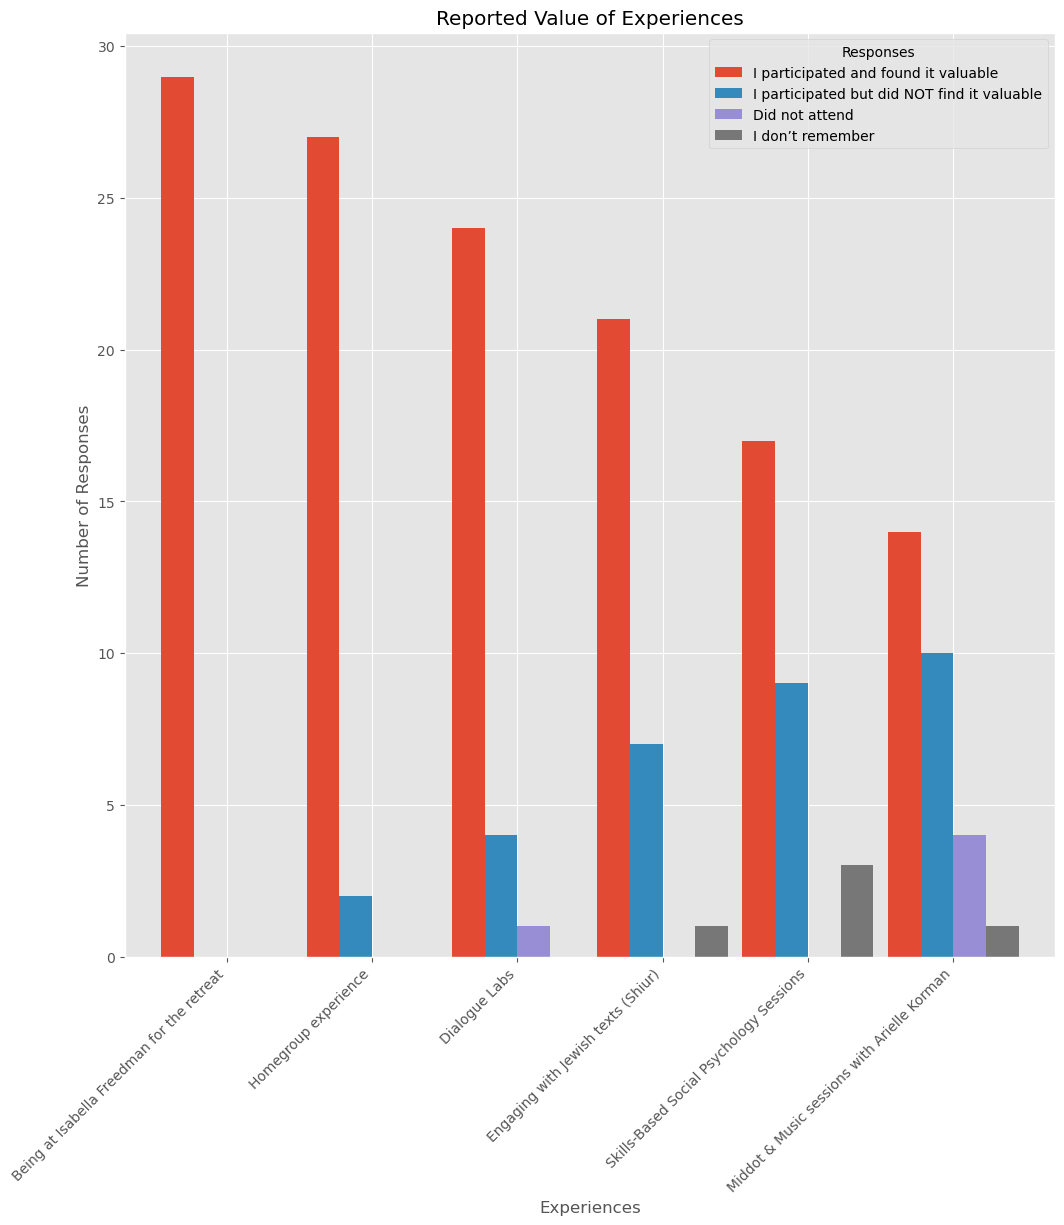

In [226]:
df_value.plot(kind='bar',
              figsize=(12,12), 
              width=0.9,
              xlabel='Experiences',
              ylabel='Number of Responses',
              title='Reported Value of Experiences',
)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Responses')
plt.show()